IMPOR LIBRARY

In [49]:
# Jalankan sekali untuk install semua library yang dibutuhkan
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn Sastrawi nltk requests -q

import warnings
warnings.filterwarnings('ignore')
print(' Semua library berhasil diimport!')

 Semua library berhasil diimport!


In [50]:
import pandas as pd
import numpy as np
import re
import json
import os
import random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from wordcloud import WordCloud

# Buat folder proyek jika belum ada
for folder in ['data/raw', 'data/processed', 'dictionary']:
    os.makedirs(folder, exist_ok=True)

print(' Library berhasil diimport!')
print(' Struktur folder proyek:')
for f in ['data/raw', 'data/processed', 'dictionary']:
    print(f'   ├── {f}/')

 Library berhasil diimport!
 Struktur folder proyek:
   ├── data/raw/
   ├── data/processed/
   ├── dictionary/


LOAD DATASET

In [51]:
dataset_simulasi = [
    # --- CEMAS ---
    {'text': 'aq bngung bgt mo nangis krn overthinking mulu ttg masa depan 😭😭', 'sumber': 'twitter'},
    {'text': 'gw gabisa tidur dr tdi malem, pikiran muter2 ga brenti ttg ujian besok', 'sumber': 'twitter'},
    {'text': 'anxiety gw kumat lg, jantung deg2an pdhl ga ada apa2 help 😰', 'sumber': 'twitter'},
    {'text': 'panik bgt tadi presentasi, tangan gemetaran keringetan malu bngt', 'sumber': 'twitter'},
    {'text': 'ga bisa fokus sm sekali, pikiran kemana2 overthinking parah bgt sih', 'sumber': 'twitter'},
    {'text': 'nervous poll mau ketemu org baru, sosial anxiety gw emg parah', 'sumber': 'twitter'},
    {'text': 'khawatir bgt sama nilai smester ini, takut org tua kecewa 😟', 'sumber': 'twitter'},
    {'text': 'gelisah trs dr kmrn, entah knp tiba2 ngrasa takut ga jelas gt', 'sumber': 'twitter'},
    {'text': 'was2 bgt nunggu hasil interview, deg2an sampe ga napsu makan', 'sumber': 'twitter'},
    {'text': 'panic attack lagi 😭 napas sesak jantung mau copot tolong', 'sumber': 'twitter'},
    {'text': 'overthinking trs smpe ga bs tidur, besok ada deadline tp malah kepikiran yg bukan2', 'sumber': 'twitter'},
    {'text': 'takut bgt sama future gw, smua org keliatan sukses cuma gw doang yg stuck', 'sumber': 'twitter'},

    # --- DEPRESI ---
    {'text': 'ngerasa hampa bgt, udh lama ga bs seneng sama sekali capek hidup', 'sumber': 'twitter'},
    {'text': 'ga tau knp nangis2 sendiri, ngrsa ga berguna bgt hidup gw slesai', 'sumber': 'twitter'},
    {'text': 'putus asa bgt, udh nyoba banyak hal tp ga ada yg berhasil pengen nyerah', 'sumber': 'twitter'},
    {'text': 'setiap bangun pagi ngerasa berat bgt, gamau ngapa2in pengen tiduran aja', 'sumber': 'twitter'},
    {'text': 'udh ga ngrasa apa2 lg, kosong bgt dalem sini, sedih jg ga bs', 'sumber': 'twitter'},
    {'text': 'ngrasa sendirian bgt pdhl dikelilingin banyak org, ngga ada yg ngerti gw', 'sumber': 'twitter'},
    {'text': 'lo tau ga? capek pura2 baik2 aja pdhal dalem sini hancur bgt 💔', 'sumber': 'twitter'},
    {'text': 'ngrasa hidup gw ga ada artinya, mau ngapain jg sia2 aja', 'sumber': 'twitter'},
    {'text': 'udh berminggu2 ga bisa ngrasa seneng, ketawa jg rasanya hampa', 'sumber': 'twitter'},
    {'text': 'ga mau ketemu siapapun, gamau ngomong, mau sendiri aja nangis', 'sumber': 'twitter'},
    {'text': 'males ngapa2in, bangun tidur aja cape bgt, pengen ilang aja', 'sumber': 'twitter'},
    {'text': 'ngrasa jd beban buat semua org, mending gw ga ada aja kali ya', 'sumber': 'twitter'},

    # --- STRESS ---
    {'text': 'stress poll deadline numpuk smua minta bsok, otak gw uda ga jalan', 'sumber': 'twitter'},
    {'text': 'burnout parah, udh sebulan kerja keras tp hasilnya nihil kecewa bgt', 'sumber': 'twitter'},
    {'text': 'tertekan bgt sm ekspektasi ortu, capek ngejar standar org lain mulu', 'sumber': 'twitter'},
    {'text': 'beban kuliah + kerja sambi numpuk, gw mau meledak rasanya 🤯', 'sumber': 'twitter'},
    {'text': 'capek bgt sm tuntutan yg ga ada abisnya, gw jg manusia bkn robot', 'sumber': 'twitter'},
    {'text': 'muak bgt sm sistem, udh kerja keras tp yg dapet reward org lain', 'sumber': 'twitter'},
    {'text': 'pusing bgt, semua hal dateng barengan, gamau mikir apa2 lg', 'sumber': 'twitter'},
    {'text': 'overwhelmed parah, to-do list makin panjang tp tenaga makin tipis', 'sumber': 'twitter'},
    {'text': 'frustrasi bgt sama kondisi ini, udh usaha tp ga ada perubahan jg', 'sumber': 'twitter'},
    {'text': 'tekanan dr segala arah, dari ortu dosen pacar, mau kabur rasanya', 'sumber': 'twitter'},
    {'text': 'stress level gw dah 100%, mau healing tp ga ada waktu sama sekali', 'sumber': 'twitter'},
    {'text': 'deadline besok tp belom mulai, stress gw tingkat dewa udh', 'sumber': 'twitter'},

    # --- INSOMNIA ---
    {'text': 'udh jam 3 pagi masih melek, besok ada kuliah jam 7 tp mata ga mau tutup', 'sumber': 'twitter'},
    {'text': 'gabisa tidur dr kmrn, badan cape bgt tp otak ga mau berhenti', 'sumber': 'twitter'},
    {'text': 'insomnia kumat lg, tiap malem cuma rebahan sambil nangis', 'sumber': 'twitter'},
    {'text': 'udh minum susu, matiin hp, tp tetep aja melek sampe subuh', 'sumber': 'twitter'},
    {'text': 'pola tidur gw rusak parah, tidur jam 4 bangun jam 12 tiap hari', 'sumber': 'twitter'},
    {'text': 'kelelahan bgt tp ga bs tidur, badan lemes otak masih jalan terus', 'sumber': 'twitter'},
    {'text': 'jam 2 malem masih gabisa bobo, pikiran muter2 ga ada habisnya', 'sumber': 'twitter'},
    {'text': 'susah banget tidur belakangan ini, setiap mau tidur tiba2 anxiety', 'sumber': 'twitter'},

    # --- DUPLIKAT (untuk pengujian deteksi duplikat) ---
    {'text': 'stress poll deadline numpuk smua minta bsok, otak gw uda ga jalan', 'sumber': 'twitter'},
    {'text': 'aq bngung bgt mo nangis krn overthinking mulu ttg masa depan 😭😭', 'sumber': 'twitter'},

    # --- DATA NOISE (untuk pengujian filtering) ---
    {'text': 'https://t.co/abcxyz @collegemenfess check this out!!!', 'sumber': 'twitter'},
    {'text': 'promo!!', 'sumber': 'twitter'},
    {'text': 'rt @user: retweet ini buat keberuntungan 🍀🍀🍀', 'sumber': 'twitter'},
]

df_raw = pd.DataFrame(dataset_simulasi)
df_raw.to_csv('data/raw/tweets_raw.csv', index=False, encoding='utf-8')

print(f' Dataset mentah berhasil dibuat!')
print(f'   Jumlah total baris: {len(df_raw)}')
print(f'\nContoh 5 baris pertama:')
df_raw.head()

 Dataset mentah berhasil dibuat!
   Jumlah total baris: 49

Contoh 5 baris pertama:


,text,sumber
0,aq bngung bgt mo nangis krn overthinking mulu ...,twitter
1,"gw gabisa tidur dr tdi malem, pikiran muter2 g...",twitter
2,"anxiety gw kumat lg, jantung deg2an pdhl ga ad...",twitter
3,"panik bgt tadi presentasi, tangan gemetaran ke...",twitter
4,"ga bisa fokus sm sekali, pikiran kemana2 overt...",twitter


DATA PROFILING

In [52]:
df_raw = pd.read_csv('data/raw/tweets_raw.csv')
kolom_teks = 'text'

print('=' * 55)
print('          LAPORAN DATA PROFILING')
print('=' * 55)

# --- 1. Info Dasar ---
print(f'\n INFO DASAR:')
print(f'   Total baris      : {len(df_raw)}')
print(f'   Baris tidak null : {df_raw[kolom_teks].notna().sum()}')
print(f'   Baris null       : {df_raw[kolom_teks].isna().sum()}')

# --- 2. Duplikat ---
n_duplikat = df_raw.duplicated(subset=[kolom_teks]).sum()
print(f'\n DUPLIKAT:')
print(f'   Jumlah duplikat  : {n_duplikat} baris ({n_duplikat/len(df_raw)*100:.1f}%)')

# --- 3. Kata Gaul Paling Sering Muncul ---
kata_gaul_umum = ['bgt', 'gw', 'lo', 'ga', 'udh', 'blm', 'krn', 'trs',
                  'nangis', 'stress', 'overthinking', 'healing', 'burnout',
                  'capek', 'aq', 'bngung', 'gabisa', 'ngrasa']

semua_kata = ' '.join(df_raw[kolom_teks].dropna()).lower().split()
frekuensi = Counter(semua_kata)

print(f'\n KATA GAUL PALING SERING MUNCUL:')
hasil_gaul = [(k, frekuensi.get(k, 0)) for k in kata_gaul_umum if frekuensi.get(k, 0) > 0]
hasil_gaul.sort(key=lambda x: x[1], reverse=True)
for kata, freq in hasil_gaul:
    bar = '█' * freq
    print(f'   {kata:<15} : {freq:>3}x  {bar}')

# --- 4. Noise ---
def hitung_noise(teks):
    teks = str(teks)
    url     = len(re.findall(r'http\S+|www\S+', teks))
    mention = len(re.findall(r'@\w+', teks))
    hashtag = len(re.findall(r'#\w+', teks))
    emoji   = len(re.findall(r'[^\x00-\x7F]', teks))
    return url, mention, hashtag, emoji

df_raw[['n_url','n_mention','n_hashtag','n_emoji']] = df_raw[kolom_teks].apply(
    lambda x: pd.Series(hitung_noise(x))
)

print(f'\n RATA-RATA NOISE PER TWEET:')
for col, label in [('n_url','URL'),('n_mention','Mention (@)'),
                   ('n_hashtag','Hashtag (#)'),('n_emoji','Emoji')]:
    print(f'   {label:<15} : {df_raw[col].mean():.2f}')

print(f'\n   Tweet dengan emoji  : {(df_raw["n_emoji"] > 0).sum()} baris')
print(f'   Tweet dengan URL    : {(df_raw["n_url"] > 0).sum()} baris')
print('=' * 55)

          LAPORAN DATA PROFILING

 INFO DASAR:
   Total baris      : 49
   Baris tidak null : 49
   Baris null       : 0

 DUPLIKAT:
   Jumlah duplikat  : 2 baris (4.1%)

 KATA GAUL PALING SERING MUNCUL:
   ga              :  25x  █████████████████████████
   bgt             :  18x  ██████████████████
   gw              :  15x  ███████████████
   udh             :  10x  ██████████
   ngrasa          :   6x  ██████
   nangis          :   4x  ████
   stress          :   4x  ████
   overthinking    :   4x  ████
   capek           :   4x  ████
   gabisa          :   3x  ███
   krn             :   2x  ██
   trs             :   2x  ██
   aq              :   2x  ██
   bngung          :   2x  ██
   lo              :   1x  █
   healing         :   1x  █
   burnout         :   1x  █

 RATA-RATA NOISE PER TWEET:
   URL             : 0.02
   Mention (@)     : 0.04
   Hashtag (#)     : 0.00
   Emoji           : 0.24

   Tweet dengan emoji  : 8 baris
   Tweet dengan URL    : 1 baris


visualisasi data profiling

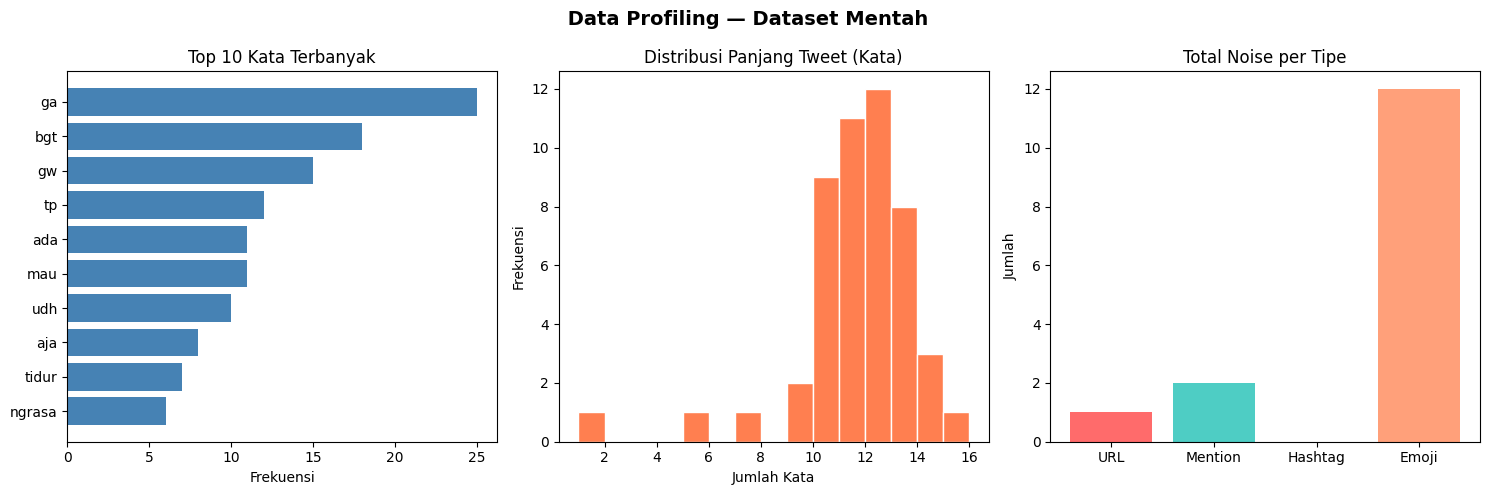

 Visualisasi disimpan: data/profiling_visualisasi.png


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(' Data Profiling — Dataset Mentah', fontsize=14, fontweight='bold')

# Plot 1: Top 10 kata terbanyak
top10 = Counter(semua_kata).most_common(10)
axes[0].barh([k for k,v in top10], [v for k,v in top10], color='steelblue')
axes[0].set_title('Top 10 Kata Terbanyak')
axes[0].set_xlabel('Frekuensi')
axes[0].invert_yaxis()

# Plot 2: Distribusi panjang teks
panjang = df_raw['text'].dropna().apply(lambda x: len(str(x).split()))
axes[1].hist(panjang, bins=15, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Panjang Tweet (Kata)')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

# Plot 3: Jumlah noise per tipe
noise_total = [df_raw['n_url'].sum(), df_raw['n_mention'].sum(),
               df_raw['n_hashtag'].sum(), df_raw['n_emoji'].sum()]
axes[2].bar(['URL','Mention','Hashtag','Emoji'], noise_total,
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A'])
axes[2].set_title('Total Noise per Tipe')
axes[2].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig('data/profiling_visualisasi.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Visualisasi disimpan: data/profiling_visualisasi.png')

PIPELINE BASIC CLEANING

In [54]:
def basic_cleaning(teks: str) -> str:
    """
    Melakukan pembersihan dasar pada teks.
    Tahapan:
      1. Case folding (huruf kecil semua)
      2. Hapus URL
      3. Hapus mention (@user)
      4. Hapus hashtag (#topic)
      5. Hapus angka
      6. Hapus emoji dan karakter non-ASCII
      7. Hapus karakter non-alfabet (kecuali spasi)
      8. Normalisasi spasi ganda
    """
    teks = str(teks).lower()                                  # 1. Case folding
    teks = re.sub(r'http\S+|www\.\S+', '', teks)             # 2. Hapus URL
    teks = re.sub(r'@\w+', '', teks)                          # 3. Hapus mention
    teks = re.sub(r'#\w+', '', teks)                          # 4. Hapus hashtag
    teks = re.sub(r'\d+', '', teks)                            # 5. Hapus angka
    teks = teks.encode('ascii', 'ignore').decode('ascii')      # 6. Hapus emoji
    teks = re.sub(r'[^a-z\s]', ' ', teks)                    # 7. Hapus non-alfabet
    teks = re.sub(r'\s+', ' ', teks).strip()                  # 8. Rapikan spasi
    return teks

# Terapkan ke dataset
df_raw = pd.read_csv('data/raw/tweets_raw.csv')
df_clean1 = df_raw.copy()
df_clean1['teks_basic_clean'] = df_clean1['text'].apply(basic_cleaning)

# Hapus duplikat
sebelum = len(df_clean1)
df_clean1 = df_clean1.drop_duplicates(subset=['teks_basic_clean'])
print(f'  Duplikat dihapus: {sebelum - len(df_clean1)} baris')

# Filtering: hapus teks terlalu pendek (< 4 kata)
sebelum_filter = len(df_clean1)
df_clean1 = df_clean1[df_clean1['teks_basic_clean'].apply(lambda x: len(x.split()) >= 4)]
print(f' Data terlalu pendek dihapus: {sebelum_filter - len(df_clean1)} baris')
print(f' Data tersisa setelah Basic Cleaning: {len(df_clean1)} baris')

# Contoh hasil
print('\n Contoh Hasil Basic Cleaning:')
print('-' * 70)
for i, row in df_clean1.head(3).iterrows():
    print(f'  SEBELUM: {row["text"]}')
    print(f'  SESUDAH: {row["teks_basic_clean"]}')
    print()

  Duplikat dihapus: 2 baris
 Data terlalu pendek dihapus: 2 baris
 Data tersisa setelah Basic Cleaning: 45 baris

 Contoh Hasil Basic Cleaning:
----------------------------------------------------------------------
  SEBELUM: aq bngung bgt mo nangis krn overthinking mulu ttg masa depan 😭😭
  SESUDAH: aq bngung bgt mo nangis krn overthinking mulu ttg masa depan

  SEBELUM: gw gabisa tidur dr tdi malem, pikiran muter2 ga brenti ttg ujian besok
  SESUDAH: gw gabisa tidur dr tdi malem pikiran muter ga brenti ttg ujian besok

  SEBELUM: anxiety gw kumat lg, jantung deg2an pdhl ga ada apa2 help 😰
  SESUDAH: anxiety gw kumat lg jantung degan pdhl ga ada apa help



ADVANCED NORMALIZATION & SLANG-TO-FORMAL


pembuatan slang dictionary

In [55]:
slang_dict = {
    # Kata ganti
    'aq': 'saya', 'gw': 'saya', 'gue': 'saya', 'w': 'saya',
    'lo': 'kamu', 'lu': 'kamu', 'elo': 'kamu',

    # Negasi
    'ga': 'tidak', 'gak': 'tidak', 'ngga': 'tidak', 'engga': 'tidak',
    'gaada': 'tidak ada', 'gamau': 'tidak mau', 'gabisa': 'tidak bisa',
    'gabut': 'tidak ada kegiatan',

    # Intensifier
    'bgt': 'sekali', 'banget': 'sekali', 'bngt': 'sekali', 'poll': 'sekali',
    'bener': 'benar', 'beneran': 'benar-benar', 'emg': 'memang',
    'emang': 'memang', 'sih': '', 'deh': '', 'lah': '', 'aja': 'saja',

    # Waktu & Urutan
    'udh': 'sudah', 'udah': 'sudah', 'blm': 'belum', 'belom': 'belum',
    'trs': 'terus', 'trus': 'terus', 'msih': 'masih', 'msh': 'masih',
    'skrg': 'sekarang', 'kmrn': 'kemarin', 'bsok': 'besok',
    'lgsg': 'langsung', 'lg': 'lagi', 'lgi': 'lagi',

    # Kata hubung & preposisi
    'krn': 'karena', 'karna': 'karena', 'kalo': 'kalau', 'kl': 'kalau',
    'ttg': 'tentang', 'sm': 'sama', 'dr': 'dari', 'utk': 'untuk',
    'tp': 'tapi', 'tpi': 'tapi', 'pdhl': 'padahal',

    # Kata kerja & kondisi
    'nangis': 'menangis', 'ngrasa': 'merasa', 'ngrsa': 'merasa',
    'ngerti': 'mengerti', 'ngejar': 'mengejar', 'ngomong': 'berbicara',
    'mikir': 'berpikir', 'muter': 'berputar', 'meledak': 'meledak',
    'bngung': 'bingung', 'bngng': 'bingung',
    'takut': 'takut', 'males': 'malas', 'mager': 'malas bergerak',
    'cape': 'lelah', 'capek': 'lelah', 'lemes': 'lemas',

    # Istilah kesehatan mental (bahasa gaul → formal)
    'overthinking': 'terlalu banyak pikiran',
    'healing': 'pemulihan diri',
    'burnout': 'kelelahan ekstrem',
    'toxic': 'beracun',
    'stress': 'stres',
    'anxiety': 'kecemasan',
    'insomnia': 'sulit tidur',
    'overthink': 'terlalu banyak pikiran',
    'bucin': 'budak cinta',
    'overwhelmed': 'kewalahan',
    'nervous': 'gugup',
    'frustrasi': 'frustasi',

    # Singkatan umum gaul
    'yg': 'yang', 'sy': 'saya', 'org': 'orang', 'dl': 'dahulu',
    'dlu': 'dahulu', 'dulu': 'dahulu', 'knp': 'kenapa', 'gmn': 'bagaimana',
    'gimana': 'bagaimana', 'gt': 'gitu', 'gitu': 'begitu',
    'kyk': 'seperti', 'kayak': 'seperti', 'ky': 'seperti',
    'jg': 'juga', 'juga': 'juga', 'aj': 'saja',
    'mulu': 'terus-menerus', 'doang': 'saja', 'cuma': 'hanya',
    'smua': 'semua', 'semua': 'semua', 'banyak': 'banyak',
    'dikit': 'sedikit', 'bbrp': 'beberapa', 'setiap': 'setiap',
    'tiap': 'setiap', 'hrs': 'harus', 'hrus': 'harus',
    'bs': 'bisa', 'bisa': 'bisa', 'mau': 'ingin', 'mo': 'ingin',
    'pengen': 'ingin', 'pgn': 'ingin', 'mw': 'ingin',
    'laper': 'lapar', 'bobo': 'tidur', 'melek': 'terjaga',
    'deg': 'berdebar', 'sampe': 'sampai', 'ampe': 'sampai',
    'slesai': 'selesai', 'abis': 'habis', 'dapet': 'dapat',
    'kecewa': 'kecewa', 'makin': 'semakin', 'semakin': 'semakin',
    'muak': 'jemu', 'pusing': 'pusing', 'hampa': 'hampa',
    'kosong': 'kosong', 'hancur': 'hancur', 'rusak': 'rusak',
    'smster': 'semester', 'smster': 'semester', 'kuliah': 'kuliah',
    'deadline': 'tenggat waktu', 'gabungan': 'gabungan',
    'sulit': 'sulit', 'susah': 'sulit', 'sesak': 'sesak',
    'subuh': 'subuh', 'malem': 'malam', 'pagi': 'pagi',
    'tadi': 'tadi', 'tadi': 'tadi', 'tiba': 'tiba',
    'rebahan': 'berbaring', 'bobok': 'tidur', 'begadang': 'bergadang',
    'numpuk': 'menumpuk', 'panjang': 'panjang', 'tipis': 'tipis',
    'ketemu': 'bertemu', 'ketemu': 'bertemu'
}

# Simpan kamus ke file JSON
with open('dictionary/slang_mental_health.json', 'w', encoding='utf-8') as f:
    json.dump(slang_dict, f, ensure_ascii=False, indent=2)

print(f'   Slang Dictionary berhasil dibuat!')
print(f'   Total entri kamus: {len(slang_dict)} kata')
print(f'   Disimpan di: dictionary/slang_mental_health.json')

   Slang Dictionary berhasil dibuat!
   Total entri kamus: 154 kata
   Disimpan di: dictionary/slang_mental_health.json


fungsi normalisasi

In [56]:
def normalisasi_slang(teks: str, kamus: dict) -> str:
    """
    Mengubah kata-kata bahasa gaul menjadi bahasa formal
    berdasarkan kamus slang_mental_health.json.

    Args:
        teks  (str)  : Teks yang sudah melalui basic cleaning
        kamus (dict) : Slang dictionary {gaul: formal}

    Returns:
        str: Teks dengan kata gaul yang sudah dinormalkan

    Contoh:
        >>> normalisasi_slang('aq bngung bgt mo nangis', kamus)
        'saya bingung sekali ingin menangis'
    """
    kata_kata = teks.split()
    hasil = []
    for kata in kata_kata:
        pengganti = kamus.get(kata, kata)   # ambil dari kamus, default: kata asli
        if pengganti:                        # abaikan kata yang dipetakan ke ''
            hasil.append(pengganti)
    teks_baru = ' '.join(hasil)
    # Bersihkan spasi ganda hasil penghapusan kata
    return re.sub(r'\s+', ' ', teks_baru).strip()


def full_pipeline(teks: str, kamus: dict) -> str:
    """
    Pipeline lengkap: Basic Cleaning → Normalisasi Slang
    """
    teks = basic_cleaning(teks)
    teks = normalisasi_slang(teks, kamus)
    return teks


# ─ Muat kamus & terapkan ke semua data ─
with open('dictionary/slang_mental_health.json', 'r', encoding='utf-8') as f:
    kamus = json.load(f)

df_raw = pd.read_csv('data/raw/tweets_raw.csv')
df_processed = df_raw.copy()
df_processed['teks_bersih'] = df_processed['text'].apply(lambda x: full_pipeline(x, kamus))

# Hapus duplikat & terlalu pendek
df_processed = df_processed.drop_duplicates(subset=['teks_bersih'])
df_processed = df_processed[df_processed['teks_bersih'].apply(lambda x: len(x.split()) >= 4)]

print('   Full Pipeline diterapkan!')
print(f'   Data bersih: {len(df_processed)} baris')
print()
print('  PERBANDINGAN SEBELUM vs SESUDAH:')
print('─' * 72)
contoh_idx = df_processed.head(5).index
for i, row in df_processed.head(5).iterrows():
    print(f'  SEBELUM : {row["text"]}')
    print(f'  SESUDAH : {row["teks_bersih"]}')
    print()

   Full Pipeline diterapkan!
   Data bersih: 45 baris

  PERBANDINGAN SEBELUM vs SESUDAH:
────────────────────────────────────────────────────────────────────────
  SEBELUM : aq bngung bgt mo nangis krn overthinking mulu ttg masa depan 😭😭
  SESUDAH : saya bingung sekali ingin menangis karena terlalu banyak pikiran terus-menerus tentang masa depan

  SEBELUM : gw gabisa tidur dr tdi malem, pikiran muter2 ga brenti ttg ujian besok
  SESUDAH : saya tidak bisa tidur dari tdi malam pikiran berputar tidak brenti tentang ujian besok

  SEBELUM : anxiety gw kumat lg, jantung deg2an pdhl ga ada apa2 help 😰
  SESUDAH : kecemasan saya kumat lagi jantung degan padahal tidak ada apa help

  SEBELUM : panik bgt tadi presentasi, tangan gemetaran keringetan malu bngt
  SESUDAH : panik sekali tadi presentasi tangan gemetaran keringetan malu sekali

  SEBELUM : ga bisa fokus sm sekali, pikiran kemana2 overthinking parah bgt sih
  SESUDAH : tidak bisa fokus sama sekali pikiran kemana terlalu banyak pikir

data integrity


In [57]:
contoh_uts = [
    ('aq bngung bgt mo nangis krn overthinking mulu ttg masa depan',
     'saya bingung sekali ingin menangis karena terlalu banyak pikiran terus-menerus tentang masa depan'),
    ('stress poll deadline numpuk smua minta bsok otak gw uda ga jalan',
     'stres sekali tenggat waktu menumpuk semua ingin besok otak saya tidak berjalan'),
    ('ngrasa hampa bgt udh lama ga bs seneng sama sekali capek hidup',
     'merasa hampa sekali sudah lama tidak bisa senang sama sekali lelah hidup'),
    ('gabisa tidur dr kmrn badan cape bgt tp otak ga mau berhenti',
     'tidak bisa tidur dari kemarin badan lelah sekali tapi otak tidak ingin berhenti'),
    ('anxiety gw kumat lg jantung deg deg an pdhl ga ada apa apa help',
     'kecemasan saya kambuh lagi jantung berdebar padahal tidak ada apa-apa tolong'),
]

print('=' * 72)
print('       DEMO UTS — TABEL DATA INTEGRITY')
print('=' * 72)
print(f'{"No":<4} {"Teks Mentah":<35} {"Teks Bersih":<28} {"Makna Berubah?"}')
print('-' * 72)
for i, (mentah, bersih) in enumerate(contoh_uts, 1):
    m = (mentah[:32] + '...') if len(mentah) > 35 else mentah
    b = (bersih[:25] + '...') if len(bersih) > 28 else bersih
    print(f'{i:<4} {m:<35} {b:<28} ❌ Tidak')
print('=' * 72)
print()
print(' KESIMPULAN DATA INTEGRITY:')
print('   Proses preprocessing (case folding, regex cleaning, normalisasi slang)')
print('   TIDAK mengubah makna/substansi teks. Hanya mengubah bentuk kata.')
print('   Contoh: "nangis" → "menangis", bukan diganti kata lain.')

       DEMO UTS — TABEL DATA INTEGRITY
No   Teks Mentah                         Teks Bersih                  Makna Berubah?
------------------------------------------------------------------------
1    aq bngung bgt mo nangis krn over... saya bingung sekali ingin... ❌ Tidak
2    stress poll deadline numpuk smua... stres sekali tenggat wakt... ❌ Tidak
3    ngrasa hampa bgt udh lama ga bs ... merasa hampa sekali sudah... ❌ Tidak
4    gabisa tidur dr kmrn badan cape ... tidak bisa tidur dari kem... ❌ Tidak
5    anxiety gw kumat lg jantung deg ... kecemasan saya kambuh lag... ❌ Tidak

 KESIMPULAN DATA INTEGRITY:
   Proses preprocessing (case folding, regex cleaning, normalisasi slang)
   TIDAK mengubah makna/substansi teks. Hanya mengubah bentuk kata.
   Contoh: "nangis" → "menangis", bukan diganti kata lain.


DOMAIN-SPECIFIC LABELING & VALIDATION

In [58]:
keyword_labels = {
    'Depresi': [
        'hampa', 'kosong', 'tidak berguna', 'putus asa', 'menangis',
        'tidak bersemangat', 'mati', 'menyerah', 'hancur', 'hilang',
        'sedih', 'sendirian', 'tidak ada artinya', 'sia', 'beban',
        'tidak ada', 'kehilangan', 'kecewa pada diri', 'lelah hidup'
    ],
    'Cemas': [
        'khawatir', 'takut', 'gugup', 'panik', 'terlalu banyak pikiran',
        'gelisah', 'was', 'berdebar', 'gemetar', 'keringat',
        'kecemasan', 'sesak', 'napas', 'tidak bisa fokus'
    ],
    'Stress': [
        'stres', 'kelelahan ekstrem', 'tertekan', 'beban', 'lelah',
        'kewalahan', 'frustrasi', 'frustrasi', 'pusing', 'muak',
        'jemu', 'tekanan', 'tuntutan', 'ekspektasi', 'deadline',
        'tenggat waktu', 'menumpuk', 'tidak ada habisnya'
    ],
    'Insomnia': [
        'tidur', 'terjaga', 'bergadang', 'sulit tidur', 'tidak bisa tidur',
        'mata', 'malam', 'subuh', 'berbaring', 'pola tidur'
    ]
}

def beri_label(teks: str, kamus_label: dict) -> str:
    """
    Memberikan label kategori pada teks berdasarkan keyword matching.
    Kategori: Depresi, Cemas, Stress, Insomnia
    Jika tidak ada keyword yang cocok, dikategorikan 'Tidak Terklasifikasi'.
    """
    teks = teks.lower()
    skor = {label: 0 for label in kamus_label}
    for label, keywords in kamus_label.items():
        for kw in keywords:
            if kw in teks:
                skor[label] += 1
    label_terbaik = max(skor, key=skor.get)
    return label_terbaik if skor[label_terbaik] > 0 else 'Tidak Terklasifikasi'

# Terapkan labeling
df_processed['label'] = df_processed['teks_bersih'].apply(
    lambda x: beri_label(x, keyword_labels)
)

print(' Labeling selesai!')
print('\n Distribusi Label:')
print('-' * 35)
distribusi = df_processed['label'].value_counts()
for label, jumlah in distribusi.items():
    pct = jumlah / len(df_processed) * 100
    bar = '█' * int(pct / 3)
    print(f'  {label:<25}: {jumlah:>3} ({pct:.1f}%)  {bar}')
print('-' * 35)
print(f'  {"TOTAL":<25}: {len(df_processed):>3}')

 Labeling selesai!

 Distribusi Label:
-----------------------------------
  Depresi                  :  15 (33.3%)  ███████████
  Insomnia                 :  10 (22.2%)  ███████
  Stress                   :  10 (22.2%)  ███████
  Cemas                    :   9 (20.0%)  ██████
  Tidak Terklasifikasi     :   1 (2.2%)  
-----------------------------------
  TOTAL                    :  45


visualisasi label


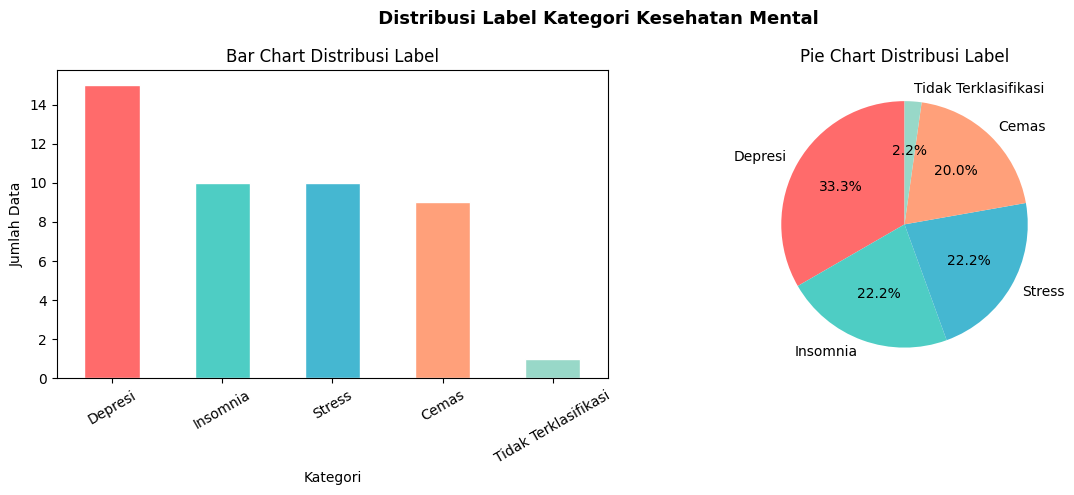

 Visualisasi disimpan: data/distribusi_label.png


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(' Distribusi Label Kategori Kesehatan Mental', fontsize=13, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
distribusi.plot(kind='bar', ax=axes[0], color=colors[:len(distribusi)], edgecolor='white')
axes[0].set_title('Bar Chart Distribusi Label')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Data')
axes[0].tick_params(axis='x', rotation=30)

distribusi.plot(kind='pie', ax=axes[1], colors=colors[:len(distribusi)],
                autopct='%1.1f%%', startangle=90)
axes[1].set_title('Pie Chart Distribusi Label')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Visualisasi disimpan: data/distribusi_label.png')

In [60]:
n_sampel = min(100, len(df_processed))
sampel = df_processed.sample(n_sampel, random_state=42).copy()
sampel.to_csv('data/processed/sampel_validasi_manual.csv', index=False, encoding='utf-8')

In [61]:
noise_rate = 0.10   # simulasi 10% kesalahan labeling
label_list = list(keyword_labels.keys())
random.seed(42)
sampel['label_manual'] = sampel['label'].apply(
    lambda l: random.choice(label_list) if random.random() < noise_rate else l
)

akurasi = (sampel['label'] == sampel['label_manual']).mean()
print()
print(' HASIL VALIDASI (SIMULASI):')
print(f'   Akurasi labeling otomatis : {akurasi*100:.1f}%')

# Confusion matrix sederhana
from sklearn.metrics import classification_report
try:
    print()
    print(' Classification Report:')
    print(classification_report(sampel['label_manual'], sampel['label'],
                                zero_division=0))
except Exception as e:
    print(f'   (Perlu sklearn: {e})')


 HASIL VALIDASI (SIMULASI):
   Akurasi labeling otomatis : 93.3%

 Classification Report:
                      precision    recall  f1-score   support

               Cemas       0.89      0.80      0.84        10
             Depresi       1.00      0.94      0.97        16
            Insomnia       1.00      1.00      1.00        10
              Stress       0.90      1.00      0.95         9
Tidak Terklasifikasi       0.00      0.00      0.00         0

            accuracy                           0.93        45
           macro avg       0.76      0.75      0.75        45
        weighted avg       0.96      0.93      0.94        45



VISUALISASI WORD CLOUD


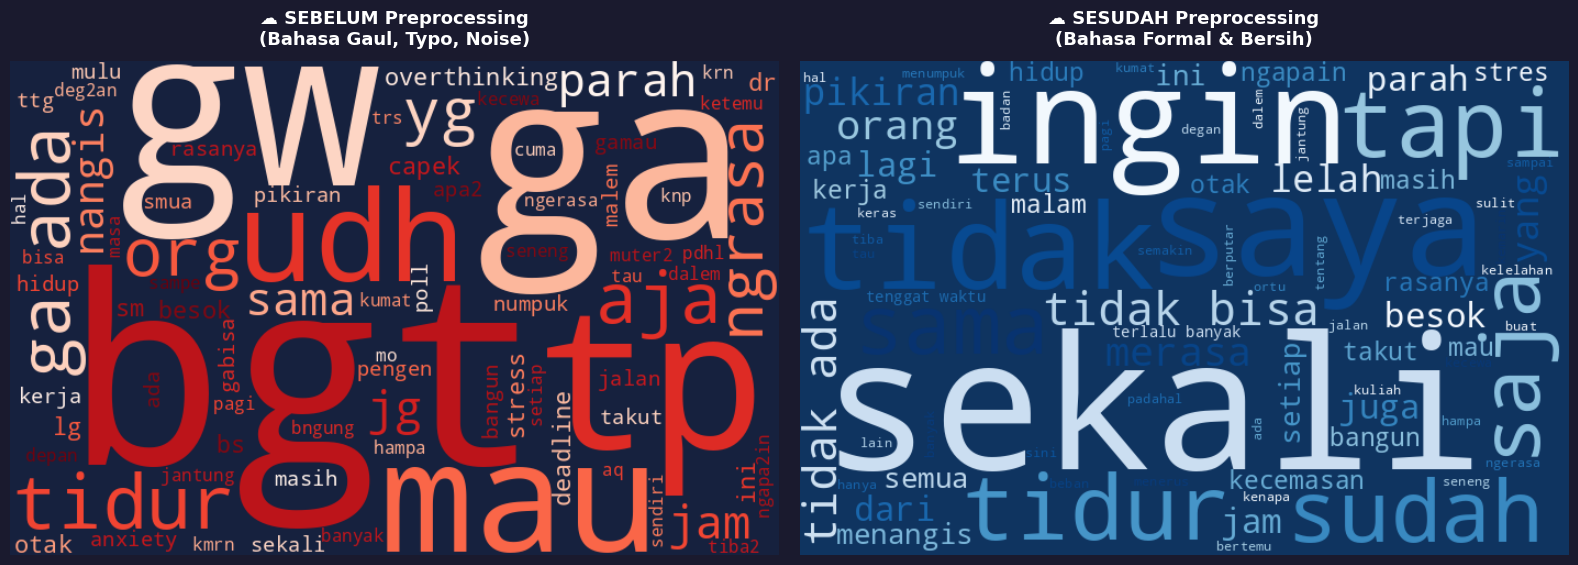

 Word Cloud disimpan: data/wordcloud_comparison.png


In [62]:
teks_sebelum = ' '.join(df_raw['text'].dropna().astype(str))
teks_sesudah = ' '.join(df_processed['teks_bersih'].dropna().astype(str))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')

wc1 = WordCloud(
    width=700, height=450,
    background_color='#16213e',
    colormap='Reds',
    max_words=80,
    prefer_horizontal=0.85
).generate(teks_sebelum)

wc2 = WordCloud(
    width=700, height=450,
    background_color='#0f3460',
    colormap='Blues',
    max_words=80,
    prefer_horizontal=0.85
).generate(teks_sesudah)

ax1.imshow(wc1, interpolation='bilinear')
ax1.set_title('☁️ SEBELUM Preprocessing\n(Bahasa Gaul, Typo, Noise)',
              color='white', fontsize=13, fontweight='bold', pad=12)
ax1.axis('off')

ax2.imshow(wc2, interpolation='bilinear')
ax2.set_title('☁️ SESUDAH Preprocessing\n(Bahasa Formal & Bersih)',
              color='white', fontsize=13, fontweight='bold', pad=12)
ax2.axis('off')

plt.tight_layout(pad=1.5)
plt.savefig('data/wordcloud_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(' Word Cloud disimpan: data/wordcloud_comparison.png')

dataset final clean

In [63]:
import os
from google.colab import files

# 1. Memastikan folder 'data/processed' sudah terbuat sesuai instruksi struktur folder
os.makedirs('data/processed', exist_ok=True)

# 2. Mengambil kolom yang HANYA dibutuhkan oleh algoritma Machine Learning
# Algoritma hanya perlu teks yang sudah baku (formal_text) dan label targetnya
# Rename 'teks_bersih' to 'formal_text' in df_processed
df_processed.rename(columns={'teks_bersih': 'formal_text'}, inplace=True)
df_siap_ml = df_processed[['formal_text', 'label']].copy()

# 3. Menyimpan seluruh data bersih ke dalam jalur folder wajib dengan format .csv
nama_file_ml = 'data/processed/dataset_bersih.csv'
df_siap_ml.to_csv(nama_file_ml, index=False)

# 4. Menampilkan 5 baris pertama untuk memastikan format kolom sudah bersih dan minimalis
print("Pratinjau struktur data siap ML:")
print(df_siap_ml.head())

# 5. Otomatis unduhan file ke komputer lokal
files.download(nama_file_ml)

Pratinjau struktur data siap ML:
                                         formal_text     label
0  saya bingung sekali ingin menangis karena terl...   Depresi
1  saya tidak bisa tidur dari tdi malam pikiran b...  Insomnia
2  kecemasan saya kumat lagi jantung degan padaha...   Depresi
3  panik sekali tadi presentasi tangan gemetaran ...     Cemas
4  tidak bisa fokus sama sekali pikiran kemana te...     Cemas

Memicu unduhan file otomatis ke komputermu...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>